# 01 — NumPy & Pandas Essentials

**Day 2 | Data Engineering & AI Bootcamp**

NumPy and Pandas are the two most important libraries for data work in Python.
Everything in ML — model weights, feature matrices, predictions — is a NumPy array.
Pandas adds labelled rows and columns on top, making data wrangling readable and fast.

**You will build:** array ops → broadcasting → DataFrame wrangling → groupby → merge → Parquet/CSV/JSON

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from day2.numpy_pandas import (
    array_basics, broadcasting_demo, numpy_for_ml,
    create_ai_dataset, wrangling_essentials,
    groupby_operations, merge_operations, file_format_comparison,
)

sns.set_theme(style='whitegrid')
print('Setup complete ✓')

Setup complete ✓


## 1. NumPy Arrays

NumPy arrays store data in **contiguous memory** as a fixed dtype (e.g., float32).
This makes vectorised operations 50–100x faster than Python lists — no Python loop overhead.
Every ML framework (scikit-learn, PyTorch, TensorFlow) accepts and returns NumPy arrays.

> **Real world:** When a Databricks ML pipeline runs inference on 10 million rows, the feature
> matrix is a NumPy array. Looping over rows in Python would take hours; vectorised NumPy takes seconds.

In [2]:
a = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
b = np.arange(1, 6, dtype=float)

print(f'Array a:        {a}')
print(f'Sum:            {a.sum()}')
print(f'Mean:           {a.mean()}')
print(f'Std:            {a.std():.4f}')
print(f'Dot product:    {np.dot(a, b)}')
print(f'Element-wise *: {a * b}')
print(f'Reshaped:       {a.reshape(1, 5)}')
print(f'Boolean mask:   {a[a > 3]}')

# Performance comparison
import time
big = np.random.standard_normal(1_000_000)

t0 = time.perf_counter()
_ = [x**2 for x in big]
python_time = time.perf_counter() - t0

t0 = time.perf_counter()
_ = big ** 2
numpy_time = time.perf_counter() - t0

print(f'\n1M elements squared:')
print(f'  Python loop: {python_time*1000:.1f}ms')
print(f'  NumPy:       {numpy_time*1000:.2f}ms')
print(f'  Speedup:     {python_time/numpy_time:.0f}x')

Array a:        [1. 2. 3. 4. 5.]
Sum:            15.0
Mean:           3.0
Std:            1.4142
Dot product:    55.0
Element-wise *: [ 1.  4.  9. 16. 25.]
Reshaped:       [[1. 2. 3. 4. 5.]]
Boolean mask:   [4. 5.]

1M elements squared:
  Python loop: 116.8ms
  NumPy:       12.57ms
  Speedup:     9x


## 2. Broadcasting

Broadcasting lets NumPy apply operations between arrays of **different shapes** without copying data.
The smaller array is virtually "expanded" to match the larger one — no loop, no memory waste.
The rule: shapes are compatible right-to-left; missing dimensions are treated as 1.

> **Real world:** To L2-normalise a batch of 10,000 embedding vectors (each 384-dim),
> you divide the (10000, 384) matrix by a (10000, 1) norm vector.
> Broadcasting makes this one line — no Python loop.

In [3]:
# Batch of 4 embedding vectors (dim=3)
embeddings = np.array([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
    [7.0, 8.0, 9.0],
    [2.0, 4.0, 6.0],
])  # shape (4, 3)

# L2 normalise each row — broadcasting in action
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)  # (4, 1)
normalised = embeddings / norms  # (4, 3) / (4, 1) -> broadcast

print('Original embeddings:')
print(embeddings)
print(f'\nNorms per row: {norms.flatten().round(3)}')
print(f'\nNormalised (each row has norm=1):')
print(normalised.round(4))
print(f'\nNorm check (should all be 1.0): {np.linalg.norm(normalised, axis=1).round(6)}')

# Cosine similarity matrix via matrix multiply
# dot(A, A.T) when rows are unit vectors = cosine similarity matrix
sim = normalised @ normalised.T  # (4, 4)
print(f'\nCosine similarity matrix:')
print(sim.round(3))
print(f'Diagonal all 1s: {np.allclose(np.diag(sim), 1.0)}')

Original embeddings:
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]
 [2. 4. 6.]]

Norms per row: [ 3.742  8.775 13.928  7.483]

Normalised (each row has norm=1):
[[0.2673 0.5345 0.8018]
 [0.4558 0.5698 0.6838]
 [0.5026 0.5744 0.6462]
 [0.2673 0.5345 0.8018]]

Norm check (should all be 1.0): [1. 1. 1. 1.]

Cosine similarity matrix:
[[1.    0.975 0.959 1.   ]
 [0.975 1.    0.998 0.975]
 [0.959 0.998 1.    0.959]
 [1.    0.975 0.959 1.   ]]
Diagonal all 1s: True


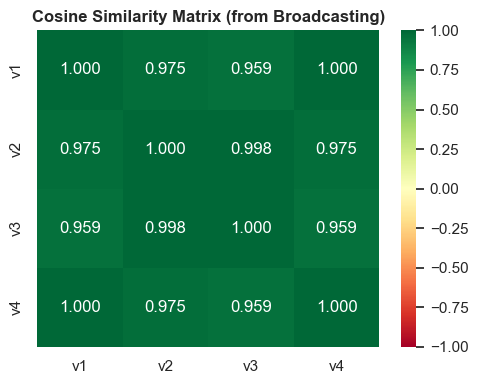

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(sim.round(3), annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=ax,
            xticklabels=['v1','v2','v3','v4'],
            yticklabels=['v1','v2','v3','v4'])
ax.set_title('Cosine Similarity Matrix (from Broadcasting)', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Pandas DataFrame — the Data Engineer's Spreadsheet

A Pandas DataFrame is a 2D table with **labelled rows and columns**, built on NumPy arrays.
Think of it as a Python Excel spreadsheet with SQL superpowers.
It is the standard format for data in ML pipelines before training.

> **Real world:** A data engineer at LTIMindtree loads transaction data from a PostgreSQL database
> into a Pandas DataFrame, cleans it, engineers features, and passes it to scikit-learn for training.
> All in Python, all readable, all testable.

In [5]:
df = create_ai_dataset()
print(f'Shape: {df.shape}  (rows × columns)')
print(f'Columns: {list(df.columns)}')
print(f'\nData types:')
print(df.dtypes)
print(f'\nFirst 5 rows:')
display(df.head())
print(f'\nBasic stats:')
display(df[['accuracy', 'f1_score', 'latency_ms']].describe().round(3))

Shape: (120, 11)  (rows × columns)
Columns: ['run_id', 'algorithm', 'dataset', 'team', 'environment', 'accuracy', 'f1_score', 'latency_ms', 'training_time_s', 'num_features', 'deployed']

Data types:
run_id                 str
algorithm              str
dataset                str
team                   str
environment            str
accuracy           float64
f1_score           float64
latency_ms         float64
training_time_s    float64
num_features         int64
deployed              bool
dtype: object

First 5 rows:


,run_id,algorithm,dataset,team,environment,accuracy,f1_score,latency_ms,training_time_s,num_features,deployed
0,run_0000,logistic_regression,mnist_small,nlp_team,prod,0.9038,0.8322,494.7,86.1,8,True
1,run_0001,svm,fraud_detection,cv_team,prod,0.6525,0.5655,282.4,266.5,8,False
2,run_0002,svm,fraud_detection,nlp_team,staging,0.8091,0.5523,421.1,60.3,8,False
3,run_0003,xgboost,mnist_small,cv_team,dev,0.8005,0.5722,495.3,30.0,128,False
4,run_0004,xgboost,sentiment,cv_team,staging,0.9345,0.8105,79.4,105.9,32,True



Basic stats:


,accuracy,f1_score,latency_ms
count,120.000,120.000,120.000
mean,0.806,0.758,271.731
std,0.111,0.123,143.704
min,0.605,0.552,12.200
25%,0.714,0.643,159.650
50%,0.809,0.768,281.600
75%,0.904,0.855,391.475
max,0.990,0.978,495.300


## 4. Data Wrangling Essentials

Data wrangling = getting raw data into a usable form. Not statistics — just practical cleanup.
The 80/20 rule: 80% of data engineering time is wrangling, 20% is analysis.
Key operations: filter rows, select columns, add derived columns, handle missing values.

> **Real world:** A model registry at Databricks stores experiment runs.
> You filter to high-accuracy runs, add a composite score column, and sort to find the
> best model to promote to production — all in a few Pandas lines.

In [7]:
# Filter
high_acc  = df[df['accuracy'] > 0.90]
prod_runs = df[df['environment'] == 'prod']

print(f'Total runs:     {len(df)}')
print(f'Accuracy > 90%: {len(high_acc)}')
print(f'Prod runs:      {len(prod_runs)}')

# Add derived columns
df['accuracy_pct']    = (df['accuracy'] * 100).round(1)
df['fast']            = df['latency_ms'] < 100
df['score_composite'] = (df['accuracy'] * 0.7 + df['f1_score'] * 0.3).round(4)

print(f'\nFast models (latency < 100ms): {df["fast"].sum()}')

# Top 5 models by composite score
top5 = df.nlargest(5, 'score_composite')[['run_id', 'algorithm', 'accuracy_pct', 'score_composite']]
print(f'\nTop 5 models:')
display(top5)

# Handle missing values
df_null = df.copy()
df_null.loc[df_null.sample(10, random_state=42).index, 'accuracy'] = None

print(f'\nNull count in accuracy: {df_null["accuracy"].isna().sum()}')
print(f'After fillna(median):   {df_null["accuracy"].fillna(df_null["accuracy"].median()).isna().sum()}')

Total runs:     120
Accuracy > 90%: 33
Prod runs:      27

Fast models (latency < 100ms): 21

Top 5 models:


,run_id,algorithm,accuracy_pct,score_composite
85,run_0085,svm,98.5,0.9575
81,run_0081,xgboost,96.5,0.9549
87,run_0087,random_forest,97.1,0.9527
20,run_0020,xgboost,95.7,0.9450
107,run_0107,svm,92.6,0.9419



Null count in accuracy: 10
After fillna(median):   0


## 5. GroupBy — SQL GROUP BY in Python

`groupby` splits the DataFrame into groups by a column, applies an aggregation function,
and combines the results. This is exactly SQL's `GROUP BY` clause.
It answers questions like: 'What is the average accuracy per algorithm?'

> **Real world:** Building a model leaderboard. You have 120 experiment runs across 5 algorithms.
> GroupBy gives you one summary row per algorithm — the standard input for a comparison dashboard.

Algorithm leaderboard:


,algorithm,runs,avg_accuracy,max_accuracy,avg_f1,avg_latency,deployed_count
0,xgboost,27,0.8246,0.9701,0.7362,267.0852,7
1,svm,32,0.8175,0.9897,0.7614,253.2156,8
2,logistic_regression,23,0.7994,0.9582,0.7831,319.1913,5
3,random_forest,17,0.7963,0.9710,0.7283,255.8529,8
4,neural_net,21,0.7807,0.9632,0.7771,266.7905,4


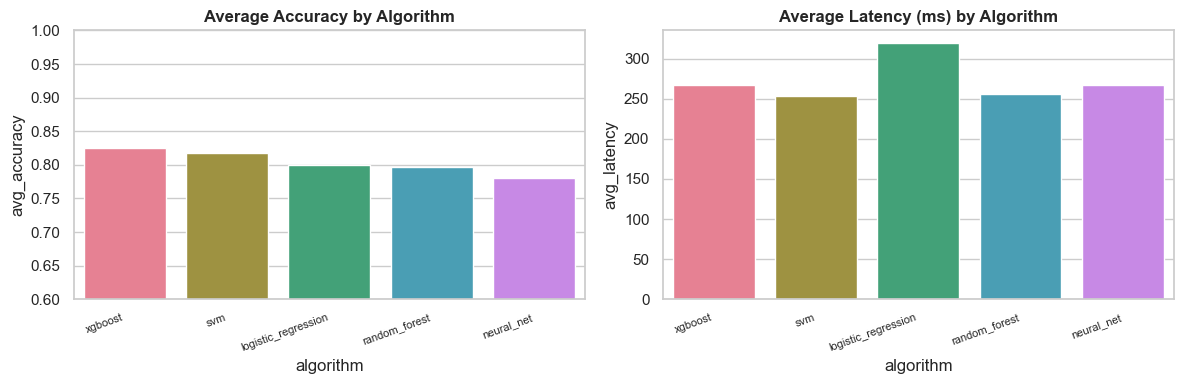

In [8]:
summary = groupby_operations(df)
print('Algorithm leaderboard:')
display(summary)

# Visualise
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=summary, x='algorithm', y='avg_accuracy', ax=ax1, palette='husl')
ax1.set_title('Average Accuracy by Algorithm', fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha='right', fontsize=8)
ax1.set_ylim(0.6, 1.0)

sns.barplot(data=summary, x='algorithm', y='avg_latency', ax=ax2, palette='husl')
ax2.set_title('Average Latency (ms) by Algorithm', fontweight='bold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Merge — SQL JOIN in Python

`merge` joins two DataFrames on a common column — exactly like SQL JOIN.
**Inner join:** only rows that match in both tables.
**Left join:** all rows from the left table, NaN where no match exists.

> **Real world:** A feature store has two tables: `runs` (experiment results) and `models` (metadata).
> A left join lets you see all runs, with model metadata where available.
> Missing metadata doesn't drop the run — it shows as NaN, which you can fill or flag.

In [9]:
runs = pd.DataFrame({
    'run_id':    ['r1', 'r2', 'r3', 'r4'],
    'algorithm': ['random_forest', 'xgboost', 'svm', 'neural_net'],
    'accuracy':  [0.92, 0.95, 0.88, 0.97],
})

models = pd.DataFrame({
    'algorithm': ['random_forest', 'xgboost', 'neural_net'],
    'owner':     ['alice',          'bob',       'carol'],
    'version':   ['v2.1',           'v1.0',      'v3.5'],
})

inner = runs.merge(models, on='algorithm', how='inner')
left  = runs.merge(models, on='algorithm', how='left')

print('INNER JOIN (only matched rows):')
display(inner)
print('\nLEFT JOIN (all runs, NaN for unmatched):')
display(left)
print(f"\n'svm' has no model metadata → owner is: {left[left['algorithm']=='svm']['owner'].values[0]}")

INNER JOIN (only matched rows):


,run_id,algorithm,accuracy,owner,version
0,r1,random_forest,0.92,alice,v2.1
1,r2,xgboost,0.95,bob,v1.0
2,r4,neural_net,0.97,carol,v3.5



LEFT JOIN (all runs, NaN for unmatched):


,run_id,algorithm,accuracy,owner,version
0,r1,random_forest,0.92,alice,v2.1
1,r2,xgboost,0.95,bob,v1.0
2,r3,svm,0.88,NaN,NaN
3,r4,neural_net,0.97,carol,v3.5



'svm' has no model metadata → owner is: nan


## 7. File Formats: Parquet, CSV, JSON

Choosing the right file format is a **data engineering decision** that affects storage cost,
query speed, and schema reliability.
- **CSV:** human-readable, universal, but NO schema enforcement and large file size.
- **JSON:** great for APIs and nested data, but verbose and slow for analytics.
- **Parquet:** columnar, compressed, typed schema — 5–10x smaller than CSV, 100x faster for analytics.

> **Real world:** Databricks Delta Lake is built on Parquet. Snowflake, BigQuery, and AWS Athena
> all use Parquet internally. Any data lake worth its name stores data as Parquet.

Dataset: 120 rows
  CSV:     11,769 bytes
  JSON:    42,708 bytes
  Parquet: 14,331 bytes
  Parquet is 1.22x the size of CSV (compressed + columnar)

Parquet preserves dtypes: True


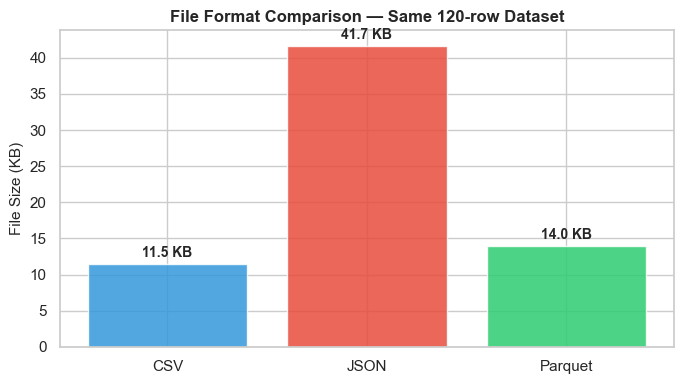

In [10]:
results = file_format_comparison(df)

formats = ['CSV', 'JSON', 'Parquet']
sizes   = [results['csv_bytes'], results['json_bytes'], results['parquet_bytes']]

print(f'Dataset: {results["rows"]} rows')
print(f'  CSV:     {results["csv_bytes"]:,} bytes')
print(f'  JSON:    {results["json_bytes"]:,} bytes')
print(f'  Parquet: {results["parquet_bytes"]:,} bytes')
print(f'  Parquet is {results["parquet_vs_csv_ratio"]:.2f}x the size of CSV (compressed + columnar)')
print(f'\nParquet preserves dtypes: {results["schemas_match"]}')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(formats, [s/1024 for s in sizes],
              color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.85, edgecolor='white')
for bar, s in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{s/1024:.1f} KB', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('File Size (KB)', fontsize=11)
ax.set_title('File Format Comparison — Same 120-row Dataset', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()